# Artificial Neural Network

### Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf

In [2]:
tf.__version__

'2.19.0'

### Importing the dataset

## Part 1 - Data Preprocessing

In [3]:
dataset = pd.read_csv('VAWT.csv')
x = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [4]:
print(x)

[[ 1.5  1. ]
 [ 0.5  0. ]
 [ 2.  -0.5]
 [ 0.5 -1. ]
 [ 1.   0. ]
 [ 3.   1.5]
 [ 2.5  0. ]
 [ 1.  -1. ]
 [ 1.5  0.5]
 [ 1.   0.5]
 [ 3.  -1.5]
 [ 1.5 -1. ]
 [ 3.  -1. ]
 [ 2.5 -0.5]
 [ 2.   0. ]
 [ 0.5  1. ]
 [ 2.   1. ]
 [ 2.5 -1. ]
 [ 1.   1.5]
 [ 2.   0.5]
 [ 0.5 -1.5]
 [ 3.  -0.5]
 [ 2.5  1.5]
 [ 1.5 -1.5]
 [ 0.5  0.5]
 [ 3.   1. ]
 [ 1.5 -0.5]
 [ 2.5 -1.5]
 [ 1.   1. ]
 [ 2.   1.5]
 [ 0.5 -0.5]
 [ 3.   0. ]
 [ 1.5  1.5]
 [ 2.5  1. ]
 [ 1.  -1.5]
 [ 2.  -1. ]
 [ 0.5  1.5]
 [ 3.   0.5]
 [ 1.  -0.5]
 [ 2.5  0.5]
 [ 2.  -1.5]
 [ 1.5  0. ]]


In [5]:
print(y)

[0.31  0.028 0.318 0.027 0.187 0.323 0.373 0.178 0.292 0.192 0.285 0.228
 0.275 0.372 0.345 0.032 0.422 0.352 0.201 0.395 0.018 0.263 0.415 0.207
 0.025 0.32  0.249 0.364 0.193 0.43  0.022 0.313 0.324 0.392 0.174 0.297
 0.036 0.318 0.186 0.384 0.283 0.274]


### Splitting the dataset into the Training set and Test set

In [6]:
from sklearn.model_selection import train_test_split , KFold
import os
import random
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)
os.environ['PYTHONHASHSEED'] = '42'
os.environ["tf_cudnn_deterministic"] = '1'
os.environ["TF_DETERMINISTIC_OPS"] = '1'
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

In [7]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train_s = sc.fit_transform(x_train)
x_test_s = sc.transform(x_test)

## Part 2 - Building the ANN

### Initializing the ANN

In [8]:
ann = tf.keras.models.Sequential([tf.keras.layers.Input(shape=(2,)),tf.keras.layers.Dense(16, activation= 'relu'),tf.keras.layers.Dense(16, activation= 'relu'),tf.keras.layers.Dense(1, activation= 'linear')])

## Part 3 - Training the ANN

### Compiling the ANN

In [9]:
ann.compile(optimizer = 'adam', loss = 'mean_squared_error' , metrics=['mae'])

### Training the ANN model on the Training set

In [10]:
es = tf.keras.callbacks.EarlyStopping(patience=200, restore_best_weights=True, monitor='val_loss')
ann.fit(x_train_s, y_train, validation_split=0.25, batch_size = 8, epochs = 4000, callbacks=[es], verbose=0)

### Predicting the results of the Test set

In [11]:
from sklearn.metrics import r2_score, mean_absolute_error
yhat_train = ann.predict(x_train_s).ravel()
y_pred = ann.predict(x_test_s).ravel()
np.set_printoptions(precision=3)
print('train R2:',r2_score(y_train, yhat_train))
print('test R2:',r2_score(y_test, y_pred))
print('test MAE:', mean_absolute_error(y_test, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
train R2: 0.9592003263314131
test R2: 0.8620861240715643
test MAE: 0.03992024766074286


In [12]:
tsr_grid = np.array([0.5,1,1.5,2,2.5,3])
fa_grid = np.array([-1.5,-1,-0.5,0,0.5,1,1.5])
TSR, FA = np.meshgrid(tsr_grid, fa_grid, indexing='ij')
grid = np.c_[TSR.ravel(), FA.ravel()]
grid_s = sc.transform(grid)
cp_pred = ann.predict(grid_s).ravel()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [13]:
best_idx = np.argmax(cp_pred)
best_tsr, best_fa, best_cp = grid[best_idx,0], grid[best_idx,1], cp_pred[best_idx]
print(f'Best (on grid): TSR= {best_tsr}, FA= {best_fa}, CP_pred= {best_cp}')

Best (on grid): TSR= 2.0, FA= 1.5, CP_pred= 0.43481284379959106


In [14]:
tsr_fine = np.linspace(0.5,3,121)
fa_fine = np.linspace(-1.5,1.5,121)
TSR_f, FA_gf = np.meshgrid(tsr_fine, fa_fine, indexing='ij')
grid_f = np.c_[TSR_f.ravel(), FA_gf.ravel()]
grid_f_s = sc.transform(grid_f)
cp_pred_f = ann.predict(grid_f_s).ravel()
best_idx_f = np.argmax(cp_pred_f)
print(f'Best (fine): TSR= {grid_f[best_idx_f,0]: .3f}, FA= {grid_f[best_idx_f,1]: .3f}, CP_pred= {cp_pred_f[best_idx_f]: .5f}')

458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Best (fine): TSR=  1.979, FA=  1.500, CP_pred=  0.43610


In [15]:
def predict_cp(tsr,fa):
  xq_s = sc.transform(np.array([[tsr,fa]]))
  return float (ann.predict(xq_s).ravel()[0])
  print(predict_cp(2.0, 2.0))

In [16]:
print(predict_cp(2, 1.5))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
0.43481284379959106


In [17]:
print(predict_cp(2, 1))
print(predict_cp(2.5, 1.5))
print(predict_cp(2, 0.5))
print(predict_cp(2.5, 1))
print(predict_cp(2.5, 0.5))
print(predict_cp(2.5, 0))
print(predict_cp(2.5, -0.5))
print(predict_cp(2.5, -1.5))
print(predict_cp(2.5, -1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
0.4232008457183838
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
0.40566563606262207
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
0.3980303406715393
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
0.3703674077987671
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
0.3791823983192444
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
0.3630509376525879
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
0.3667759895324707
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
0.3086862564086914
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
0.3459392189979553


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


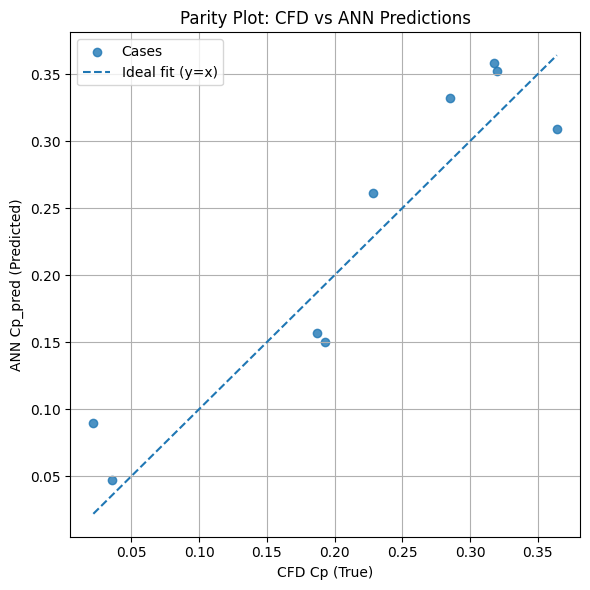

In [18]:
import numpy as np, matplotlib.pyplot as plt
plt_all_pred = ann.predict(sc.transform(x)).ravel()
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.8, label="Cases")
mn, mx = np.min([y_test.min(), y_pred.min()]), np.max([y_test.max(), y_pred.max()])
plt.plot([mn, mx], [mn, mx], linestyle="--", label="Ideal fit (y=x)")
plt.xlabel("CFD Cp (True)")
plt.ylabel("ANN Cp_pred (Predicted)")
plt.title("Parity Plot: CFD vs ANN Predictions")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("parity_plot.png", dpi=150)
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


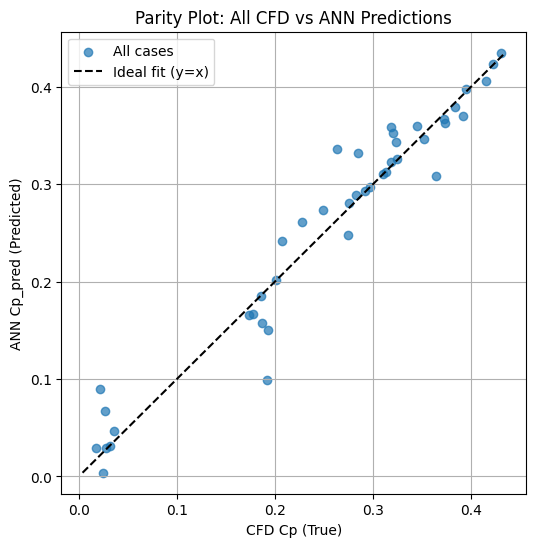

In [21]:
y_all_pred = ann.predict(sc.transform(x)).ravel()

plt.figure(figsize=(6,6))
plt.scatter(y, y_all_pred, alpha=0.7, label="All cases")
mn, mx = np.min([y.min(), y_all_pred.min()]), np.max([y.max(), y_all_pred.max()])
plt.plot([mn, mx], [mn, mx], 'k--', label="Ideal fit (y=x)")
plt.xlabel("CFD Cp (True)")
plt.ylabel("ANN Cp_pred (Predicted)")
plt.title("Parity Plot: All CFD vs ANN Predictions")
plt.legend()
plt.grid(True)
plt.show()

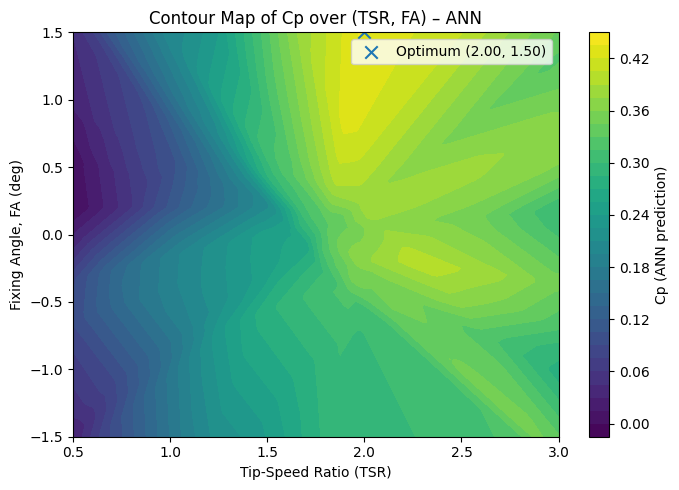

In [19]:
plt.figure(figsize=(7,5))
cs = plt.contourf(TSR_f, FA_gf, cp_pred_f.reshape(TSR_f.shape), levels=30)
plt.colorbar(cs, label="Cp (ANN prediction)")
plt.scatter([best_tsr], [best_fa], marker="x", s=80, label=f"Optimum ({best_tsr:.2f}, {best_fa:.2f})")
plt.xlabel("Tip-Speed Ratio (TSR)")
plt.ylabel("Fixing Angle, FA (deg)")
plt.title("Contour Map of Cp over (TSR, FA) – ANN")
plt.legend()
plt.tight_layout()
plt.savefig("cp_contour.png", dpi=300)
plt.show()